# Proyek Klasifikasi Gambar: [Vegetable Image Dataset]
- **Nama:** [Ananda safrida]
- **Email:** [safridaananda960@gmail.com]
- **ID Dicoding:** [CACC716D6X1987]

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing import image

## Data Preparation

In [4]:
from google.colab import files
import os

# Upload file kaggle.json
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    for fn in uploaded.keys():
        print('User uploaded file "{name}" with length {length} bytes'.format(
            name=fn, length=len(uploaded[fn])))

    # Pindahkan kaggle.json ke folder yang benar
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Download dataset langsung dari Kaggle
!kaggle datasets download -d misrakahmed/vegetable-image-dataset

# Ekstrak dataset
import zipfile
local_zip = 'vegetable-image-dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/data_proyek')
zip_ref.close()

print("Dataset berhasil diunduh dan diekstrak!")

Saving kaggle (1).json to kaggle (1).json
User uploaded file "kaggle (1).json" with length 69 bytes
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
License(s): CC-BY-SA-4.0
100% 534M/534M [00:06<00:00, 85.6MB/s]

Dataset berhasil diunduh dan diekstrak!


### Data Loading

In [28]:
import os
import shutil
import random

base_dir = '/content/data_proyek/Vegetable Images'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

classes = sorted(os.listdir(train_dir))

print(f"Base Directory: {base_dir}")
print(f"Train Directory: {train_dir}")
print(f"Validation Directory: {val_dir}")
print(f"Test Directory: {test_dir}")
print(f"Classes: {classes}")
print("Dataset paths defined successfully!")

Base Directory: /content/data_proyek/Vegetable Images
Train Directory: /content/data_proyek/Vegetable Images/train
Validation Directory: /content/data_proyek/Vegetable Images/validation
Test Directory: /content/data_proyek/Vegetable Images/test
Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Dataset paths defined successfully!


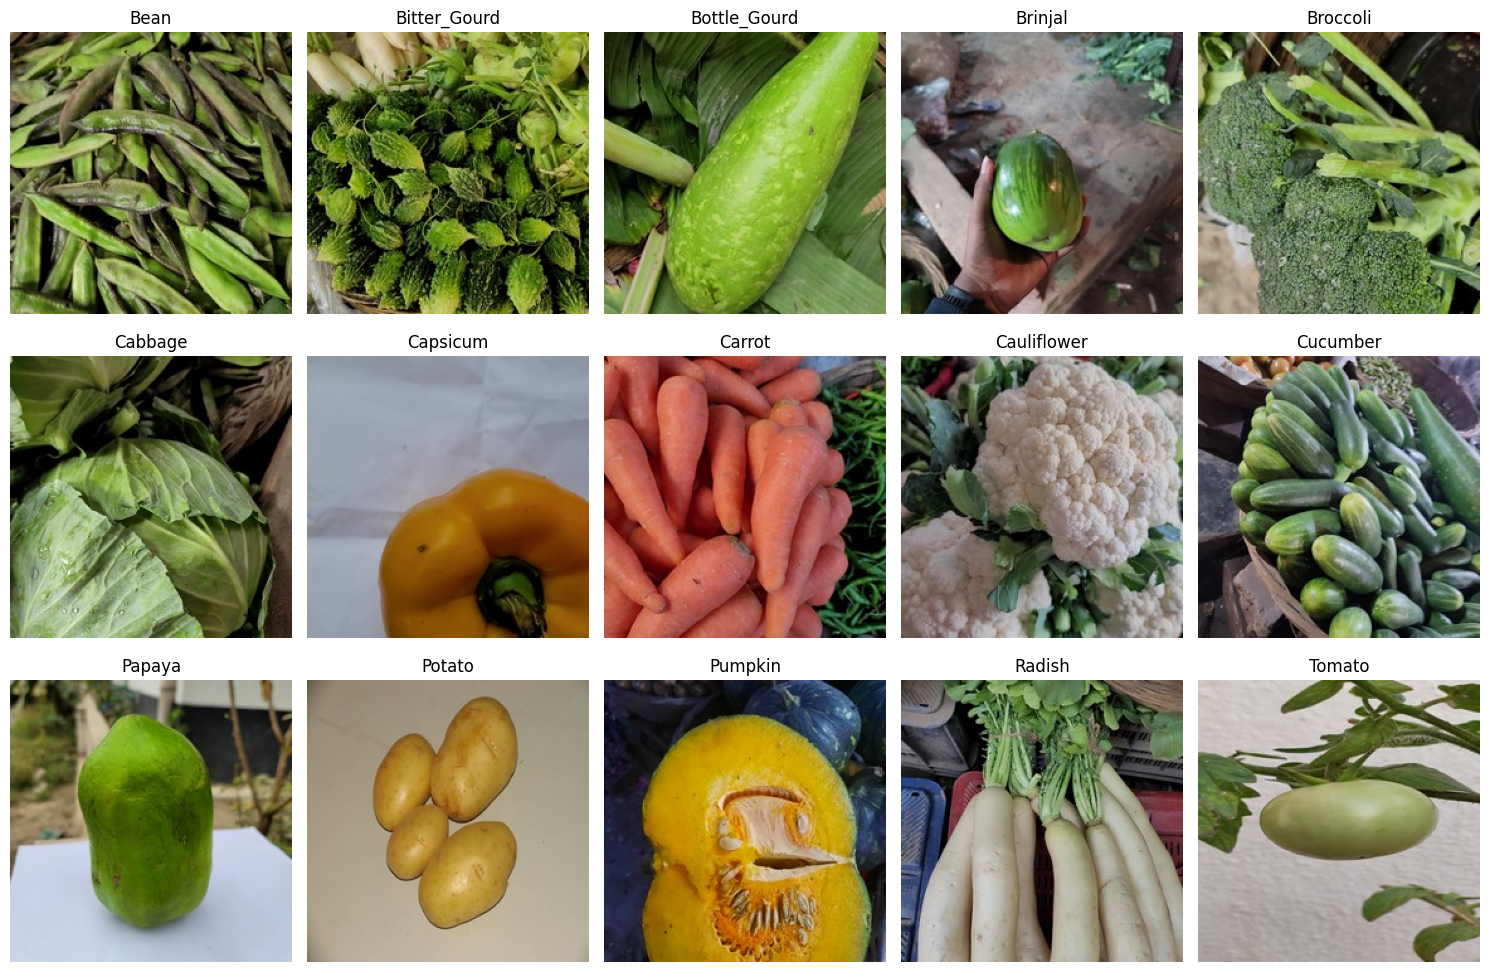

In [29]:
# visualisasi dataset
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def visualize_dataset(base_path, classes):
    plt.figure(figsize=(15, 10))

    for i, category in enumerate(classes):
        # Ambil folder tiap kelas di dalam folder train
        class_path = os.path.join(base_path, category)

        # menampilkan gambar secara acak
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        # Tampilkan gambar
        img = mpimg.imread(img_path)
        plt.subplot(3, 5, i + 1) # 3 baris, 5 kolom (karena ada 15 kelas)
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_dataset(train_dir, classes)

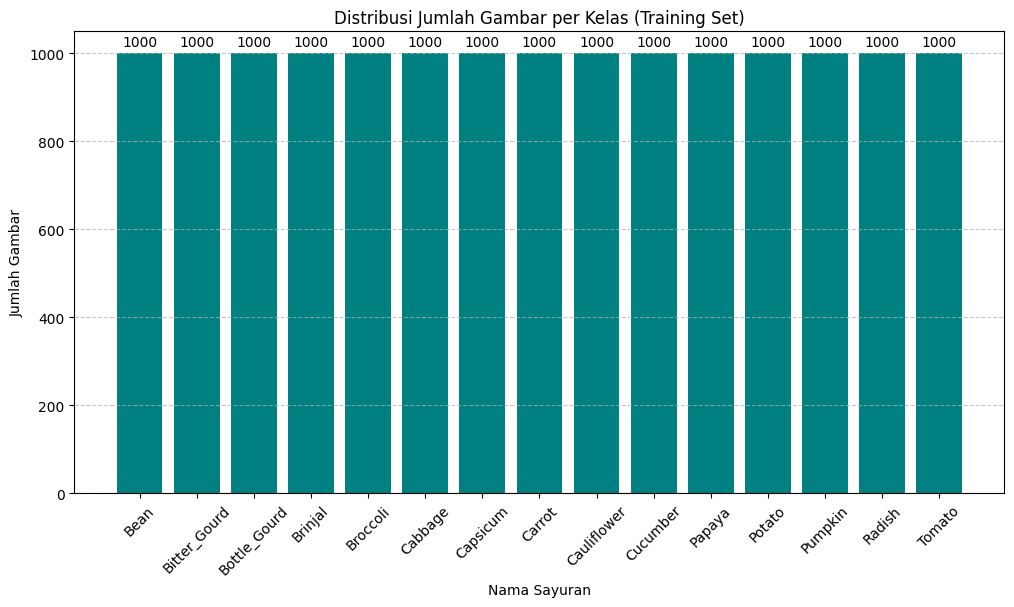

In [30]:
# visualisasi distibusi data
import matplotlib.pyplot as plt

def plot_distribution(directory, title):
    classes = sorted(os.listdir(directory))
    counts = [len(os.listdir(os.path.join(directory, c))) for c in classes]

    # Membuat diagram batang
    plt.figure(figsize=(12, 6))
    bars = plt.bar(classes, counts, color='teal')

    # Menambahkan label angka di atas batang
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 10, yval, ha='center', va='bottom')

    plt.xlabel('Nama Sayuran')
    plt.ylabel('Jumlah Gambar')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_distribution(train_dir, 'Distribusi Jumlah Gambar per Kelas (Training Set)')

### Data Preprocessing

In [33]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True, fill_mode='nearest')
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(100, 100), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(100, 100), batch_size=32, class_mode='categorical')
test_generator = val_datagen.flow_from_directory(test_dir, target_size=(100, 100), batch_size=32, class_mode='categorical')

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


#### Split Dataset

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100, 100), # Menyeragamkan semua resolusi ke 100x100
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical'
)

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


## Modelling

In [34]:
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.96 and logs.get('val_accuracy') > 0.96):
            self.model.stop_training = True

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_generator, epochs=25, validation_data=val_generator, callbacks=[MyCallback()])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 430ms/step - accuracy: 0.5851 - loss: 1.2759 - val_accuracy: 0.7587 - val_loss: 0.7260
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 411ms/step - accuracy: 0.8126 - loss: 0.5815 - val_accuracy: 0.8317 - val_loss: 0.4957
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 204s 416ms/step - accuracy: 0.8718 - loss: 0.4086 - val_accuracy: 0.8840 - val_loss: 0.3877
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 409ms/step - accuracy: 0.9073 - loss: 0.2954 - val_accuracy: 0.8970 - val_loss: 0.3630
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 406ms/step - accuracy: 0.9317 - loss: 0.2238 - val_accuracy: 0.8900 - val_loss: 0.3891
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - accuracy: 0.9407 - loss: 0.1880 - val_accuracy: 0.9210 - val_loss: 0.2810
Epoch 7/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 408ms/step - accuracy: 0.9518 - loss: 0.1575 - val_accuracy: 0.9350 - val_loss: 0.2279
Epoch 8/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 407ms/step - accuracy: 0.9543 -

## Evaluasi dan Visualisasi

94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - accuracy: 0.9580 - loss: 0.1405

Akurasi Testing: 95.80%


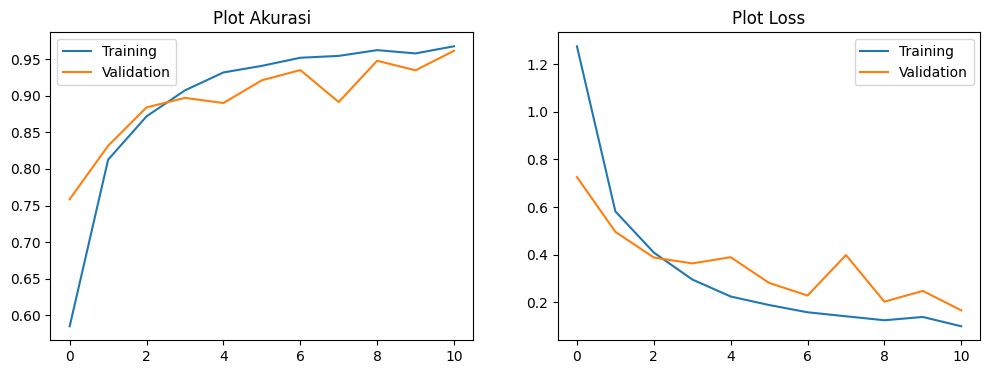

In [35]:
# Evaluasi
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi Testing: {test_acc*100:.2f}%")

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Plot Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Plot Loss')
plt.legend()
plt.show()

## Konversi Model

In [36]:
!mkdir -p submission/tfjs_model submission/tflite submission/saved_model

# SavedModel
model.export('submission/saved_model')

# TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('submission/saved_model')
tflite_model = converter.convert()
with open('submission/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)
with open('submission/tflite/label.txt', 'w') as f:
    f.write('\n'.join(classes))

# TFJS
!pip install tensorflowjs
import subprocess
subprocess.run(['tensorflowjs_converter', '--input_format=tf_saved_model', 'submission/saved_model', 'submission/tfjs_model'])

# Membuat requirements.txt
!pip freeze > submission/requirements.txt

Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor_32')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  138689385139280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138689835654928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138689385139472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138689833172624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138689833169936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138689833164176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138689833158800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138689833172432: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Inference (Optional)

In [39]:
from google.colab import files
uploaded = files.upload()

# Muat SavedModel sebagai TFSMLayer untuk Keras 3
reloaded_model = tf.keras.layers.TFSMLayer('submission/saved_model', call_endpoint='serving_default')

for fn in uploaded.keys():
    img = image.load_img(fn, target_size=(100, 100))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # Prediksi menggunakan TFSMLayer
    result = reloaded_model(tf.constant(x))
    # TFSMLayer mengembalikan dictionary, kita perlu mengambil tensor output
    result = result['output_0'].numpy()

    print(f"\nNama File: {fn}")
    print(f"Prediksi: {classes[np.argmax(result)]} ({np.max(result)*100:.2f}%)")

Saving wortel.jpg to wortel (1).jpg

Nama File: wortel (1).jpg
Prediksi: Tomato (100.00%)


In [ ]:
import shutil
from google.colab import files

submission = "submission_proyek_klasifikasi"

shutil.make_archive(submission, 'zip', 'submission')

files.download(f"{submission}.zip")

print(f"Berhasil membungkus struktur direktori ke dalam {submission}.zip")

In [22]:
with open('submission/README.md', 'w') as f:
    f.write("# Proyek Klasifikasi Gambar Sayuran\n")
    f.write("- Dataset: Vegetable Image Dataset (15.000 gambar)\n")
    f.write("- Model: Sequential (CNN)\n")
    f.write("- Target Akurasi: >95%\n")

In [23]:
import shutil
from google.colab import files

shutil.make_archive('submission_proyek', 'zip', 'submission')

files.download('submission_proyek.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>